In [1]:
# OPTIONAL: run once in a fresh Colab runtime; skip during local development.
INSTALL_COLAB_PACKAGES = False  # Set to True to install; reset to False afterward.

import sys
import subprocess

# Detect Colab; otherwise use the local .venv.
try:
    from google.colab import output
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if not IN_COLAB:
    print("Local environment: skipped. Use uv sync --group llm in your terminal.")
elif not INSTALL_COLAB_PACKAGES:
    print("Installation skipped. Set INSTALL_COLAB_PACKAGES = True if this is a fresh Colab runtime.")
else:
    if sys.version_info[:2] != (3, 13):
        raise RuntimeError("Choose a Python 3.13 Colab runtime before installing these packages.")
    # Install into the Python running these cells.
    subprocess.check_call([sys.executable, "-m", "pip", "install", "uv>=0.8,<1"])
    packages = [
        "ipython>=8,<9",
        "matplotlib-inline<0.2",
        "pandas>=2.0",
        "numpy>=1.24",
        "scikit-learn>=1.3",
        "fairlearn>=0.10",
        "matplotlib>=3.7",
        "jupyter>=1.0",
        "shap>=0.44"
    ]
    subprocess.check_call([sys.executable, "-m", "uv", "pip", "install",
                           "--python", sys.executable, *packages])
    print("Installation finished. Choose Runtime → Restart session before continuing.")

Installation finished. Choose Runtime → Restart session before continuing.


# Défi ÉquiAlgo : rapport d'audit

Ce carnet mesure le biais du comité historique et du modèle en production, justifie la métrique d'équité retenue et identifie les variables proxys.

## Contexte

En reprenant l'analyse du taux d'octroi par région, on remarque que 48.4% vont au centre et seulement 27.3% en région pour une côte R presque identique.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

demandes = pd.read_csv('data/donnees_demandes.csv')
candidats = pd.read_csv('data/candidats_evaluation.csv')


In [2]:
# Les cinq regions administratives presentes dans le jeu de donnees.
ELOIGNEES = ['Bas-Saint-Laurent', 'Cote-Nord', 'Gaspesie-Iles-de-la-Madeleine']

def groupe_region(df):
    """Regroupe les cinq regions en deux blocs : grands centres / regions eloignees."""
    return np.where(df['region_administrative'].isin(ELOIGNEES), 'Eloignee', 'Centre')

par_region = demandes.groupby('region_administrative').agg(
    candidats=('decision_octroi', 'size'),
    taux_octroi=('decision_octroi', 'mean'),
    cote_r_moyenne=('cote_r_equivalent', 'mean'),
).sort_values('taux_octroi')
print(par_region.round(3))

demandes['groupe'] = groupe_region(demandes)
print()
print(demandes.groupby('groupe')['decision_octroi'].mean().round(3))


                               candidats  taux_octroi  cote_r_moyenne
region_administrative                                                
Cote-Nord                           1178        0.263          27.325
Bas-Saint-Laurent                   1293        0.269          27.296
Gaspesie-Iles-de-la-Madeleine       1529        0.284          27.354
Montreal                            4001        0.483          27.988
Capitale-Nationale                  1999        0.484          27.984

groupe
Centre      0.484
Eloignee    0.273
Name: decision_octroi, dtype: float64


In [3]:
par_region = demandes.groupby('region_administrative').agg(
    dossiers=('decision_octroi', 'size'),
    taux_octroi=('decision_octroi', 'mean'),
    cote_r=('cote_r_equivalent', 'mean'),
    revenu=('revenu_familial_estime', 'mean'),
    heures=('heures_travail_semaine', 'mean'),
    distance_km=('distance_domicile_campus_km', 'mean'),
    premiere_gen=('premiere_generation_universitaire', 'mean'),
).sort_values('taux_octroi')
display(par_region.round(3))

,dossiers,taux_octroi,cote_r,revenu,heures,distance_km,premiere_gen
region_administrative,,,,,,,
Cote-Nord,1178,0.263,27.325,56056.296,13.115,225.934,0.428
Bas-Saint-Laurent,1293,0.269,27.296,56289.286,12.954,217.731,0.448
Gaspesie-Iles-de-la-Madeleine,1529,0.284,27.354,56576.151,13.001,221.152,0.453
Montreal,4001,0.483,27.988,75801.788,8.984,19.910,0.268
Capitale-Nationale,1999,0.484,27.984,76565.663,8.949,19.556,0.258


Les trois régions éloignées se ressemblent, tout comme les deux grands centres. Le regroupement en deux blocs ne cache donc pas de région atypique. Les candidats des régions éloignées ont une côte R légèrement plus basse (−0,7 point), un revenu familial plus bas, travaillent plus d'heures et habitent beaucoup plus loin du campus.

On remarque une grande différence d'octroi de bourse (+21 points) pour les candidats n'habitant pas dans une région éloignée.

Générons un graphique permettant de se rendre compte plus précisément du biais d'octroi par rapport à la côte R en fonction des régions.

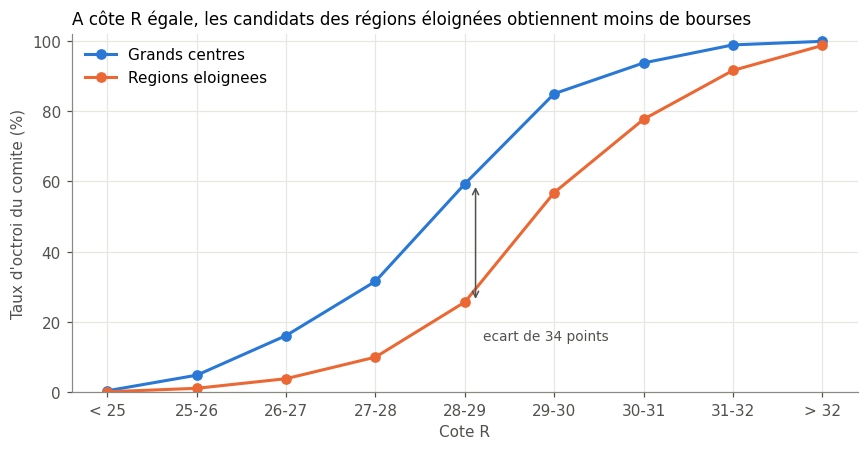

groupe,centres_%,eloignees_%,ecart_points,dossiers
< 25,0.4,0.1,0.3,1816
25-26,4.8,1.1,3.7,1009
26-27,16.1,3.8,12.3,1298
27-28,31.6,10.0,21.6,1261
28-29,59.3,25.6,33.7,1256
29-30,84.9,56.8,28.1,1092
30-31,93.7,77.6,16.1,882
31-32,98.8,91.5,7.3,618
> 32,99.8,98.6,1.2,768


In [4]:
def preparer(df):
    df = df.copy()
    df['log_revenu'] = np.log(df['revenu_familial_estime'])
    df['eloignee'] = df['region_administrative'].isin(ELOIGNEES).astype(int)
    return df

# Uniqument pour le graphique, on crée une copy pour ne pas écraser les données
demandes_copy = demandes
candidats_copy = candidats

demandes_copy = preparer(pd.read_csv('data/donnees_demandes.csv'))
candidats_copy = preparer(pd.read_csv('data/candidats_evaluation.csv'))

for df in (demandes_copy, candidats_copy):
    df['groupe'] = np.where(df['eloignee'] == 1, 'Eloignee', 'Centre')

CENTRE, ELOIGNEE, NEUTRE = '#2a78d6', '#eb6834', '#9a9890'
COULEURS = {'Centre': CENTRE, 'Eloignee': ELOIGNEE}
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e6e3', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.edgecolor': '#8a8984', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e', 'figure.dpi': 110,
})

bornes = [15, 25, 26, 27, 28, 29, 30, 31, 32, 40]
demandes_copy['tranche_r'] = pd.cut(demandes_copy['cote_r_equivalent'], bornes)
courbe = demandes_copy.groupby(['tranche_r', 'groupe'], observed=True)['decision_octroi'].agg(['mean', 'size']).unstack()
etiquettes = [f'{int(i.left)}-{int(i.right)}' if i.right - i.left == 1 else (f'< {int(i.right)}' if i.left == 15 else f'> {int(i.left)}')
              for i in courbe.index]

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(courbe))
for g, nom in [('Centre', 'Grands centres'), ('Eloignee', 'Regions eloignees')]:
    y = courbe[('mean', g)].values
    ax.plot(x, y * 100, '-o', color=COULEURS[g], lw=2, ms=6, label=nom)
i = 4
ax.annotate('', xy=(x[i] + 0.12, courbe[('mean', 'Eloignee')].iloc[i] * 100),
            xytext=(x[i] + 0.12, courbe[('mean', 'Centre')].iloc[i] * 100),
            arrowprops=dict(arrowstyle='<->', color='#52514e', lw=1))
ecart_i = (courbe[('mean', 'Centre')].iloc[i] - courbe[('mean', 'Eloignee')].iloc[i]) * 100
ax.text(x[i] + 0.2, 16, f'ecart de {ecart_i:.0f} points', color='#52514e', fontsize=9, va='center')
ax.set_xticks(x, etiquettes)
ax.set_xlabel('Cote R')
ax.set_ylabel("Taux d'octroi du comite (%)")
ax.set_ylim(0, 102)
ax.set_title("A côte R égale, les candidats des régions éloignées obtiennent moins de bourses", loc='left', fontsize=11)
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

table = courbe['mean'].mul(100).round(1).rename(columns={'Centre': 'centres_%', 'Eloignee': 'eloignees_%'})
table['ecart_points'] = (table['centres_%'] - table['eloignees_%']).round(1)
table['dossiers'] = courbe['size'].sum(axis=1).values
table.index = etiquettes
display(table)

On remarque qu'à côte R égale et notamment dans l'intervalle [28;29], une personne habitant au centre à beaucoup plus de chance d'obtenir une bourse qu'une personne habitant dans une région éloignée (34 points d'écart). L'écart tend à se réduire petit à petit car les candidats ayant une côte R très élevée sont presque assurés d'obtenir une bourse. On note tout de même qu'à partir de l'intervalle [30,33] un candidat vivant au centre est quasi-assuré d'obtenir une bourse contrairement à un candidat en région qui tournera plutôt autour de 80%. De manière générale, l'écart n'est nul qu'aux extrêmes, là où tout le monde est refusé (côte R < 25) ou accepté (côte R > 32).

On sait qu'à côte R égale, l'écart persiste. Il faut donc chercher autre chose. On peut regarder également si des candidats venant de régions éloignées ayant le même profil que des candidats du centre sont encore défavorisés.

In [5]:
from sklearn.linear_model import LogisticRegression

demandes['eloigne'] = demandes['region_administrative'].isin(ELOIGNEES).astype(int)
demandes['revenu_10k'] = demandes['revenu_familial_estime'] / 10_000
demandes['distance_100km'] = demandes['distance_domicile_campus_km'] / 100

colonnes = ['cote_r_equivalent', 'revenu_10k', 'heures_travail_semaine',
            'distance_100km', 'premiere_generation_universitaire', 'eloigne']

# Test sans distance_100km car distance et région très lié
colonnes_2 = ['cote_r_equivalent', 'revenu_10k', 'heures_travail_semaine', 'premiere_generation_universitaire', 'eloigne']

X = pd.concat([demandes[colonnes],
               pd.get_dummies(demandes['programme_etudes'], prefix='prog', drop_first=True)],
              axis=1).astype(float)

X_2 = pd.concat([demandes[colonnes_2],
               pd.get_dummies(demandes['programme_etudes'], prefix='prog', drop_first=True)],
              axis=1).astype(float)

y = demandes['decision_octroi']

modele = LogisticRegression(penalty=None, max_iter=5000).fit(X, y)
modele_without_disntance = LogisticRegression(penalty=None, max_iter=5000).fit(X_2, y)

rapports = pd.Series(np.exp(modele.coef_[0]), index=X.columns)
rapports_2 = pd.Series(np.exp(modele_without_disntance.coef_[0]), index=X_2.columns)

print(f"Rapport de côtes « éloigné » : {rapports['eloigne']:.3f}")
print(f"Rapport de côtes « éloigné » sans distance : {rapports_2['eloigne']:.3f}")

Rapport de côtes « éloigné » : 0.109
Rapport de côtes « éloigné » sans distance : 0.136


Le rapport de côtes très faible de 0.110 indique que, à profil égal, la région joue encore. Même en retirant la distance (proxy le plus logique, vérifier plus tard dans le notebook), le résultat est similaire (0.137), à cote R, programme, revenu, heures de travail et statut de première génération égaux, la région d'origine réduit fortement les chances d'octroi. Cela prouve que `decision_octroi` est biaisé.

## Mesure du biais : Quelle part des 21 points est expliquée ?

On applique la règle que le comité utilise pour les grands centres aux candidats des régions éloignées. On obtient le taux d'octroi que ces candidats auraient obtenu s'ils avaient été jugés comme les autres. C'est une décomposition de type Oaxaca-Blinder (méthode de Fairlie).

In [6]:
variables = ['cote_r_equivalent', 'log_revenu', 'heures_travail_semaine', 'premiere_generation_universitaire']
centres, eloignees = demandes_copy[demandes_copy.eloignee == 0], demandes_copy[demandes_copy.eloignee == 1]

taux = demandes_copy.groupby('groupe')['decision_octroi'].mean()
ecart_brut = taux['Centre'] - taux['Eloignee']

def taux_contrefactuel(colonnes):
    regle_centres = LogisticRegression(C=100, max_iter=5000).fit(centres[colonnes], centres['decision_octroi'])
    return regle_centres.predict_proba(eloignees[colonnes])[:, 1].mean()

contre_tout = taux_contrefactuel(variables)
contre_r = taux_contrefactuel(['cote_r_equivalent'])

decomposition = pd.DataFrame({
    'points': [ecart_brut, taux['Centre'] - contre_tout, contre_tout - taux['Eloignee']],
}, index=['ecart total', 'expliqué par le dossier', 'inexpliqué (traitement différent)']).mul(100).round(1)
decomposition['part'] = (decomposition['points'] / decomposition['points'].iloc[0]).map('{:.0%}'.format)
display(decomposition)
print(f"Taux contrefactuel des régions éloignées : {contre_tout:.1%} (dossier complet), {contre_r:.1%} (côte R seule)")

,points,part
ecart total,21.1,100%
expliqué par le dossier,4.9,23%
inexpliqué (traitement différent),16.1,76%


Taux contrefactuel des régions éloignées : 43.4% (dossier complet), 40.7% (côte R seule)


Si on regarde seulement la côte R, les régions éloignées auraient dû obtenir environ 41 % de bourses. Avec tout le dossier, environ 43 %. Elles en ont obtenu 27 %. Environ les trois quarts de l'écart ne s'expliquent pas par les dossiers.

## Chiffrer la pénalité et la règle du comité

On modélise la décision du comité avec une régression logistique lisible. Pour comparer les effets, on convertit chaque coefficient en points de cote R : combien de points de cote R il faudrait ajouter pour compenser cet effet.

In [7]:
# La distance est exclue ici
colonnes = ['cote_r_equivalent', 'log_revenu', 'heures_travail_semaine',
            'premiere_generation_universitaire', 'eloignee']
regle = LogisticRegression(C=100, max_iter=5000).fit(demandes_copy[colonnes], demandes_copy['decision_octroi'])
coef = pd.Series(regle.coef_[0], index=colonnes)
point_r = coef['cote_r_equivalent']

resume = pd.DataFrame({'coefficient': coef, 'rapport_de_cotes': np.exp(coef), 'en_points_de_cote_R': coef / point_r})
resume.loc['log_revenu', 'en_points_de_cote_R'] = coef['log_revenu'] * np.log(2) / point_r
resume = resume.rename(index={'log_revenu': 'log_revenu (par doublement)'})
display(resume.round(3))

penalite_points = -coef['eloignee'] / point_r
poids_heures = coef['heures_travail_semaine'] / point_r
print(f'Penalite regionale : {penalite_points:.2f} point de cote R')
print(f'Une heure travaillee par semaine vaut {poids_heures:.3f} point de cote R')

,coefficient,rapport_de_cotes,en_points_de_cote_R
cote_r_equivalent,1.384,3.991,1.000
log_revenu (par doublement),1.780,5.931,0.891
heures_travail_semaine,0.201,1.223,0.146
premiere_generation_universitaire,-0.053,0.948,-0.038
eloignee,-1.933,0.145,-1.397


Penalite regionale : 1.40 point de cote R
Une heure travaillee par semaine vaut 0.146 point de cote R


Lecture :
- Venir d'une région éloignée divise les chances (en cotes) par environ 7 (rapport de cotes ≈ 0,14). C'est l'équivalent de 1,4 point de cote R retiré.
- Un revenu familial deux fois plus élevé vaut environ 0,9 point de cote R. **Le comité avantage les familles aisées**.
- Chaque heure travaillée par semaine vaut environ 0,15 point de cote R. Le comité valorise les étudiants qui travaillent pendant leurs études.

## Métriques d'équité

L'audit initial du modèle de départ montre que le modèle discrimine de façon injuste les candidats des régions éloignées. Les métriques d'exactitude et de taux de vrais positifs de décision d'octroi ne sont pas adaptées et suffisantes.

Il est d'après nous plus important de s'assurer que tous les candidats qui ont réellement besoin d'une bourse l'obtiennent. Pour cela, il faut donc mesurer la précision et le rappel (taux de vrais positifs).

## Détection des proxys

Vu que le code postal est décidé géographiquement, il est attendu qu'il reflète entièrement les régions administratives. On peut dans un premier temps chercher à savoir si le code postal est une copie du paramètre région dans les données.

Si oui, c'est un argument pour le retirer du modèle solution.

In [ ]:
# nombre de candidats par (code postal, région)
croise = pd.crosstab(demandes['code_postal_3'], demandes['region_administrative'])
print(croise)
ét
# Combien de régions différentes par code postal ?
nb_regions = demandes.groupby('code_postal_3')['region_administrative'].nunique()
print(nb_regions.value_counts()) # 1 = correspondance parfaite

Le code postal détermine intégralement la région (18 codes, 18 correspondances uniques), on peut donc l'exclure du modèle.

### Quels autres paramètres peuvent déduire la région ?

Pour tenter de prédire précisément les proxys, on peut créer un petit modèle ayant pour cible la région et prenant en paramètre l'ensemble des autres colonnes. Le but de ce modèle est de voir quels paramètres permettent de déduire la région même sans que celle-ci soit explicitement donnée dans le modèle.

Regardons dans un premier temps si l'ensemble des paramètres permettent cette déduction.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif

cible = demandes['region_administrative'].isin(ELOIGNEES).astype(int)
variables = ['cote_r_equivalent', 'revenu_familial_estime', 'heures_travail_semaine', 'distance_domicile_campus_km', 'premiere_generation_universitaire']

# validation croisée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X = pd.concat([demandes[variables], pd.get_dummies(demandes['programme_etudes'], prefix='prog')], axis=1).astype(float)

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1)
proba = cross_val_predict(rf, X, cible, cv=cv, method='predict_proba')[:, 1]
print(f"AUC globale (toutes variables) : {roc_auc_score(cible, proba):.3f}")

On voit bien que les variables permettent de deviner la région, regardons maintenant quelles variables sont responsables de cette déduction.

In [ ]:
# AUC variable par variable
auc_var = {}

for v in variables:
    a = roc_auc_score(cible, demandes[v])
    auc_var[v] = max(a, 1 - a)

Xp = pd.get_dummies(demandes['programme_etudes'], drop_first=True).astype(float)
pp = cross_val_predict(LogisticRegression(max_iter=1000), Xp, cible, cv=cv, method='predict_proba')[:, 1]
a = roc_auc_score(cible, pp)
auc_var['programme_etudes'] = max(a, 1 - a)

classement = pd.DataFrame({
    'auc_seule': pd.Series(auc_var),
}).sort_values('auc_seule', ascending=False).round(3)
print(classement)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

# --- Code postal (variable catégorielle, même méthode que le programme) ---
Xcp = pd.get_dummies(demandes['code_postal_3'], drop_first=True).astype(float)
pcp = cross_val_predict(LogisticRegression(max_iter=1000), Xcp, cible, cv=cv, method='predict_proba')[:, 1]
auc_var['code_postal_3'] = roc_auc_score(cible, pcp)

classement = pd.DataFrame({'auc_seule': pd.Series(auc_var)}).sort_values('auc_seule', ascending=True)

# --- Catégories (couleur) ---
CATEGORIE = {
    'code_postal_3': 'Proxy pur',
    'distance_domicile_campus_km': 'Proxy pur',
    'heures_travail_semaine': 'Proxy légitime (besoin réel)',
    'revenu_familial_estime': 'Proxy légitime (besoin réel)',
}
COULEURS = {'Proxy pur': '#C0392B',
            'Proxy légitime (besoin réel)': '#E67E22',
            'Faible signal': '#2878D6'}
cats = [CATEGORIE.get(v, 'Faible signal') for v in classement.index]
couleurs = [COULEURS[c] for c in cats]

fig, ax = plt.subplots(figsize=(9, 4.5))
barres = ax.barh(classement.index, classement['auc_seule'], color=couleurs, height=0.55)
for b, v in zip(barres, classement['auc_seule']):
    ax.text(v + 0.006, b.get_y() + b.get_height() / 2, f'{v:.2f}', va='center', fontsize=10, color='#444')

ax.axvline(0.5, color='#999', lw=1, ls='--')
ax.set_xlim(0.5, 1.06)
ax.set_xlabel("AUC pour prédire la région à partir de la variable seule (0,5 = aucune information)")
ax.set_title("Quelles variables trahissent la région ?", loc='left', fontsize=12)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.grid(axis='x', alpha=0.25)

# Légende
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=l) for l, c in COULEURS.items()],
          loc='lower right', frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('auc_proxys.png', dpi=200, bbox_inches='tight')
plt.show()

La distance domicile-campus est le proxy principal. On remarque également que les heures de travail par semaine ainsi que le revenu familial sont des paramètres portant également de l'information, le proxy est néanmoins plus faible que `distance_domicile_campus_km`.

Pour améliorer la détection de proxy, on peut utiliser le même principe en créant testant toutes les combinaisons possibles de features et voir si ces combinaisons permettent de déduire la région.

In [ ]:
import itertools
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score

demandes = pd.read_csv('data/donnees_demandes.csv')
ELOIGNEES = ['Bas-Saint-Laurent', 'Cote-Nord', 'Gaspesie-Iles-de-la-Madeleine']
cible = demandes['region_administrative'].isin(ELOIGNEES).astype(int)   # 1 = région éloignée

# Chaque variable = un "bloc" de colonnes (le programme en compte plusieurs : une par catégorie)
variables_num = ['cote_r_equivalent', 'revenu_familial_estime', 'heures_travail_semaine',
                 'distance_domicile_campus_km', 'premiere_generation_universitaire']
blocs = {v: demandes[[v]].astype(float) for v in variables_num}
blocs['programme_etudes'] = pd.get_dummies(demandes['programme_etudes'], prefix='prog').astype(float)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def auc_combinaison(noms):
    X = pd.concat([blocs[n] for n in noms], axis=1)
    rf = RandomForestClassifier(n_estimators=100, min_samples_leaf=20, random_state=42, n_jobs=-1)
    proba = cross_val_predict(rf, X, cible, cv=cv, method='predict_proba')[:, 1]
    return roc_auc_score(cible, proba)

# Toutes les combinaisons de 1 à 6 variables
resultats = []
for k in range(1, len(blocs) + 1):
    for combo in itertools.combinations(blocs, k):
        resultats.append({'combinaison': combo, 'nb_variables': k, 'auc': auc_combinaison(combo)})

grille = pd.DataFrame(resultats)

# Gain apporté par la combinaison par rapport à la meilleure variable seule qu'elle contient
auc_seule = {r['combinaison'][0]: r['auc'] for r in resultats if r['nb_variables'] == 1}
grille['gain_vs_meilleure_seule'] = grille.apply(
    lambda r: r['auc'] - max(auc_seule[n] for n in r['combinaison']), axis=1)

grille['avec_distance'] = grille['combinaison'].apply(lambda c: 'distance_domicile_campus_km' in c)
grille['combinaison'] = grille['combinaison'].apply(lambda c: ' + '.join(c))
grille = grille.sort_values('auc', ascending=False).round(3)

In [ ]:
ABREV = {'cote_r_equivalent': 'Cote R',
         'revenu_familial_estime': 'Revenu',
         'heures_travail_semaine': 'Heures de travail',
         'distance_domicile_campus_km': 'Distance',
         'premiere_generation_universitaire': '1re génération',
         'programme_etudes': 'Programme'}

def propre(c):
    for k, v in ABREV.items():
        c = c.replace(k, v)
    return c

def meilleure_par_taille(df):
    t = df.sort_values('auc', ascending=False).groupby('nb_variables').head(1).sort_values('nb_variables').copy()
    t['combinaison'] = t['combinaison'].map(propre)
    return t[['nb_variables', 'combinaison', 'auc']].rename(
        columns={'nb_variables': 'Nb de variables', 'combinaison': 'Meilleure combinaison', 'auc': 'AUC'})

sans_dist = grille[~grille['avec_distance']]
tab = meilleure_par_taille(sans_dist)
tab['Gain vs ligne précédente'] = tab['AUC'].diff().fillna(0)

styled = (tab.style
    .hide(axis='index')
    .format({'AUC': '{:.3f}', 'Gain vs ligne précédente': '{:+.3f}'})
    .bar(subset=['AUC'], color='#7FB3E6', vmin=0.5, vmax=1.0)
    .background_gradient(subset=['Gain vs ligne précédente'], cmap='Greens', vmin=0, vmax=0.05)
    .set_caption("Reconstituer la région SANS la distance ni le code postal")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('text-align', 'left'), ('padding-bottom', '8px')]},
        {'selector': 'th', 'props': [('text-align', 'left'), ('background-color', '#F2F4F7')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}]))
display(styled)

# Version complète (avec distance) pour comparaison : une seule ligne suffit
meilleure_avec = grille[grille['avec_distance']].sort_values('auc', ascending=False).iloc[0]
print(f"\nRéférence avec la distance : AUC {meilleure_avec['auc']:.3f} "
      f"({propre(meilleure_avec['combinaison'])})")

Même sans la distance ni le code postal, les variables restantes retrouvent la région avec une AUC de 0,85, presque entièrement grâce à deux d'entre elles : les heures de travail (0,80) et le revenu, qui porte le gain à 0,83. Les autres variables n'ajoutent presque rien.

## Choix des variables

### Distribution des heures de travail

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grille de distribution pour les HEURES DE TRAVAIL par région (normalisée et lisible)
g_heures = sns.FacetGrid(
    demandes,
    col='region_administrative',
    hue='decision_octroi',
    col_wrap=3,
    height=4,
    palette='coolwarm'
)
g_heures.map_dataframe(
    sns.histplot,
    x='heures_travail_semaine',
    kde=True,
    element='step',      # Utilise un style escalier pour éviter le chevauchement des barres
    alpha=0.2,           # Transparence douce pour le remplissage
    stat='percent',      # Affiche des pourcentages
    common_norm=False    # Normalise indépendamment chaque groupe (0 et 1) pour égaliser les hauteurs
)
g_heures.add_legend(title="Décision d'octroi")
g_heures.set_titles("{col_name}")
g_heures.set_axis_labels("Heures de travail par semaine", "Pourcentage de candidats (%)")
plt.subplots_adjust(top=0.9)
g_heures.fig.suptitle('Distribution des heures de travail par région administrative (normalisée)', fontsize=14)
plt.show()

Nous conservons les heures de travail. Elles pèsent dans le même sens dans les cinq régions et avec une force comparable dans les deux groupes : ce n'est pas par ce critère que le comité pénalise les régions. Les candidats éloignés travaillent davantage, ce qui reflète un besoin financier réel. Le retirer pénaliserait précisément ceux que la bourse doit aider.

Être un proxy ne suffit pas pour exclure une variable. Les heures travaillées révèlent en partie la région, mais elles mesurent aussi un effort réel. Les retirer pénaliserait justement les étudiants des régions, qui travaillent plus. C'est un choix éthique assumé, documenté ici.

| Variable | AUC | Effet sur la décision, à région égale | Décision |
|---|---|---|---|
| `code_postal_3` | 1,00 | copie exacte de la région | exclue du modèle |
| `distance_domicile_campus_km` | 1,00 | aucun | exclue : proxy pur |
| `heures_travail_semaine` | 0,81 | positif, identique dans les deux groupes | conservée : travailler pendant ses études est un mérite légitime |
| `revenu_familial_estime` | 0,69 | positif : avantage légèrement les familles aisées | neutralisée : critère inéquitable pour une bourse, et proxy |
| `premiere_generation_universitaire` | 0,59 | nul | conservée, sans effet |
| `cote_r_equivalent` | 0,56 | critère principal | conservée |
| `programme_etudes` | 0,55 | négligeable | conservée |

## Parité démographique VS égalité des chances

**IMPORTANT** : On note dans la description du sujet que le même modèle évalue à la fois les demandes de bourses d'excellence ET les demandes de prêts d'études. Une bourse d'excellence et un prêt d'études ne poursuivent pas le même but éthique : la bourse veut récompenser les meilleurs étudiants tandis que le prêt vise plutôt à aider des étudiants dont le besoin financier est plus important pour pouvoir entreprendre leurs études.

Une bonne chose serait donc peut-être de créer deux modèles différents, cela permettrait de faire des choix plus judicieux et donc par extension de réduire les biais.

| | Parité démographique | Égalité des chances (retenue) |
|---|---|---|
| **Question** | Chaque groupe reçoit-il le même pourcentage de bourses ? | Parmi ceux qui méritent la bourse, chaque groupe a-t-il la même chance de l'obtenir ? |
| **Tient compte du mérite** | Non | Oui |
| **Risque** | Accorder des quotas, refuser des candidats plus méritants | Dépend de la définition du mérite |

Selon notre vision, la bourse d'excellence prime ici, on ne souhaite pas refuser des fonds à des élèves méritants au profit d'élèves potentiellement moins compétents. Aussi, on pense que le système doit répondre à cette question : "À qualifications, besoins et conditions pertinentes comparables, le système donne-t-il aux personnes de chaque région une chance comparable, et ses erreurs sont-elles réparties équitablement ?"

Nous choisissons donc de défendre **l'égalité des chances** : les candidat·es qui ont des qualifications et des besoins comparables doivent avoir des chances comparables d'obtenir une bourse. La parité démographique forcerait des quotas, et nous la rapportons comme mesure secondaire.

Néanmoins il est important de reconnaître que des critères comme le revenu, la distance ou la première génération universitaire peuvent corriger des désavantages réels.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

CATEGORIELLES = ['programme_etudes', 'region_administrative', 'code_postal_3']

def encoder(df_entrainement, df_cible):
    """Encode les colonnes categorielles et aligne les colonnes des deux tableaux.

    L'alignement (reindex) est important : si une categorie est absente d'un des
    deux jeux, get_dummies produit un nombre de colonnes different et le modele
    echoue - ou pire, apprend sur les mauvaises colonnes.
    """
    X = pd.get_dummies(
        df_entrainement.drop(columns=['id_candidat', 'decision_octroi', 'groupe'], errors='ignore'),
        columns=CATEGORIELLES,
    )
    Xc = pd.get_dummies(
        df_cible.drop(columns=['id_candidat', 'decision_octroi', 'groupe'], errors='ignore'),
        columns=CATEGORIELLES,
    ).reindex(columns=X.columns, fill_value=0)
    return X, Xc

# Decoupage interne pour mesurer honnetement la performance.
train, test = train_test_split(
    demandes, test_size=0.3, random_state=42, stratify=demandes['decision_octroi']
)
X_train, X_test = encoder(train, test)
y_train, y_test = train['decision_octroi'], test['decision_octroi']

modele = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42)
modele.fit(X_train, y_train)
y_pred = modele.predict(X_test)

print(f'Exactitude globale : {accuracy_score(y_test, y_pred):.2%}')
print()
print(classification_report(y_test, y_pred, digits=3))
